# Project 4: Machine Learning Analysis of Multimodal Health Dataset
## Target: Depression Severity Prediction (PHQ-9)

**Dataset:** Loneliness and Well-being in Finnish Immigrants — 39 participants, 28 days  
**Prediction Task:** Binary classification — High vs Low depression severity based on PHQ-9 scores  
**Data Sources Used:** Oura Ring, AWARE Smartphone (screen, calls, battery), EMA daily mood surveys


## 0. Import Libraries

In [2]:
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

print('All libraries loaded successfully!')

All libraries loaded successfully!


---
## Task 1: Dataset Understanding

**Purpose:** The dataset was collected to study loneliness and well-being among Finnish immigrants using passive sensing and self-report measures over 28 days.

**Data Types Collected:**
- Smartphone behavioral data (AWARE app): screen usage, calls, battery
- Wearable data (Oura Ring): sleep, activity, heart rate, HRV, readiness
- EMA daily mood surveys: loneliness, connectedness, isolation, positive/negative affect
- Psychological surveys: PHQ-9 (weekly), Beck Depression Inventory, UCLA Loneliness, PSS

**Research Applications:**
- Predicting mental health states from passive sensing
- Understanding behavioral correlates of loneliness and depression
- Digital phenotyping for mental health monitoring in immigrant populations

---
## Task 2: Data Exploration

In [3]:
# Set dataset path
DATASET_PATH = "/Users/jakes0221/Downloads/Loneliness_Dataset_Nov10"

participant_folders = sorted([
    f for f in glob.glob(os.path.join(DATASET_PATH, "Participant_*"))
    if os.path.isdir(f)
])

print(f"Found {len(participant_folders)} participant folders")
for p in participant_folders[:5]:
    print(" ", os.path.basename(p))

Found 39 participant folders
  Participant_1
  Participant_10
  Participant_11
  Participant_12
  Participant_13


In [4]:
# Explore structure of one participant
sample = participant_folders[0]
print(f"Structure of: {os.path.basename(sample)}")
for root, dirs, files in os.walk(sample):
    # Skip Watch folder (raw sensor data, not used)
    dirs[:] = [d for d in dirs if d != 'Watch']
    level = root.replace(sample, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files:
        print(f"{indent}  {f}")

Structure of: Participant_1
Participant_1/
  .DS_Store
  Aware/
    screen.csv
    calls.csv
    battery.csv
  Oura/
    oura_data_Participant_1.csv
  Surveys/
    Perceived stress every week_Participant_1.csv
    Short Form Health Survey at the beginning_Participant_1.csv
    Beck Depression Inventory at the beginning_Participant_1.csv
    ema_data_Participant_1.csv
    Social connectedness at the beginning_Participant_1.csv
    Perceived stress at the beginning_Participant_1.csv
    Patient Health Questionnaire every week_Participant_1.csv
    Perceived stress at the END_Participant_1.csv
    Sense of Coherence at the beginning_Participant_1.csv
    Twente Engagement with Ehealth Technologies at the beginning_Participant_1.csv
    Short Form Health Survey at the END_Participant_1.csv
    Twente Engagement with Ehealth Technologies at the END_Participant_1.csv
    UCLA Loneliness at the END_Participant_1.csv
    Social connectedness at the END_Participant_1.csv
    Sense of Coherence 

In [5]:
# Summary of data sources
print("=== Dataset Summary ===")
print(f"Participants: {len(participant_folders)}")
print(f"Study duration: 28 days")
print(f"\nData sources per participant:")
print(f"  Oura Ring    : 1 CSV file (sleep, activity, HRV, readiness)")
print(f"  AWARE App    : 3 CSV files (screen.csv, calls.csv, battery.csv)")
print(f"  EMA Surveys  : 1 CSV file (daily mood: lonely, connect, isolate, positive, negative)")
print(f"  PHQ-9 Weekly : 1 CSV file (q1-q9, multiple weekly responses)")
print(f"  Watch        : Raw sensor data (PPG, accelerometer) — skipped due to complexity")

=== Dataset Summary ===
Participants: 39
Study duration: 28 days

Data sources per participant:
  Oura Ring    : 1 CSV file (sleep, activity, HRV, readiness)
  AWARE App    : 3 CSV files (screen.csv, calls.csv, battery.csv)
  EMA Surveys  : 1 CSV file (daily mood: lonely, connect, isolate, positive, negative)
  PHQ-9 Weekly : 1 CSV file (q1-q9, multiple weekly responses)
  Watch        : Raw sensor data (PPG, accelerometer) — skipped due to complexity


---
## Task 3: Data Preprocessing & Feature Extraction

### 3.1 — Oura Ring Features

In [15]:
def load_oura_features(participant_folders):
    """
    Load Oura Ring data and aggregate per-participant.
    Columns confirmed from dataset: OURA_sleep_*, OURA_activity_*, OURA_readiness_*
    """
    records = []

    for folder in participant_folders:
        pid = os.path.basename(folder)
        oura_dir = os.path.join(folder, "Oura")
        if not os.path.isdir(oura_dir):
            continue

        csv_files = glob.glob(os.path.join(oura_dir, "*.csv"))
        participant_dfs = []
        for f in csv_files:
            try:
                df = pd.read_csv(f)
                participant_dfs.append(df)
            except:
                pass

        if not participant_dfs:
            continue

        combined = pd.concat(participant_dfs, ignore_index=True)

        # Exact column names confirmed from dataset
        feature_cols = {
            'sleep_duration':   'OURA_sleep_duration',
            'sleep_total':      'OURA_sleep_total',
            'sleep_deep':       'OURA_sleep_deep',
            'sleep_rem':        'OURA_sleep_rem',
            'sleep_light':      'OURA_sleep_light',
            'sleep_score':      'OURA_sleep_score',
            'sleep_efficiency': 'OURA_sleep_efficiency',
            'sleep_hr_avg':     'OURA_sleep_hr_average',
            'sleep_hr_lowest':  'OURA_sleep_hr_lowest',
            'sleep_hrv':        'OURA_sleep_rmssd',
            'activity_steps':   'OURA_activity_steps',
            'activity_score':   'OURA_activity_score',
            'activity_cal':     'OURA_activity_cal_active',
            'activity_high':    'OURA_activity_high',
            'activity_medium':  'OURA_activity_medium',
            'activity_low':     'OURA_activity_low',
            'readiness_score':  'OURA_readiness_score',
            'readiness_hrv':    'OURA_readiness_score_hrv_balance',
        }

        row = {'participant_id': pid}
        for feat_name, col in feature_cols.items():
            if col in combined.columns:
                vals = pd.to_numeric(combined[col], errors='coerce')
                row[f'oura_{feat_name}_mean'] = vals.mean()
                row[f'oura_{feat_name}_std']  = vals.std()
            else:
                row[f'oura_{feat_name}_mean'] = np.nan
                row[f'oura_{feat_name}_std']  = np.nan

        records.append(row)

    return pd.DataFrame(records)

oura_features = load_oura_features(participant_folders)
print(f"Oura features shape: {oura_features.shape}")
print(oura_features.head())

Oura features shape: (38, 37)
   participant_id  oura_sleep_duration_mean  oura_sleep_duration_std  \
0   Participant_1              27844.285714              4386.644232   
1  Participant_10              34778.571429              4110.903041   
2  Participant_11              29751.724138              4006.503703   
3  Participant_12              26280.000000              3684.540677   
4  Participant_13              30496.551724              3372.447475   

   oura_sleep_total_mean  oura_sleep_total_std  oura_sleep_deep_mean  \
0           25609.285714           3898.163792          13987.500000   
1           28082.142857           2952.862211           7534.285714   
2           26262.413793           3795.025555           6495.517241   
3           22529.032258           2590.125293           8917.741935   
4           24363.103448           2386.870491           7601.379310   

   oura_sleep_deep_std  oura_sleep_rem_mean  oura_sleep_rem_std  \
0          2898.374544          4040.

### 3.2 — AWARE Smartphone Features

In [16]:
def load_aware_features(participant_folders):
    """
    Load AWARE smartphone data and aggregate per-participant.
    Files: screen.csv, calls.csv, battery.csv
    Columns confirmed from dataset.
    """
    records = []

    for folder in participant_folders:
        pid = os.path.basename(folder)
        aware_dir = os.path.join(folder, "Aware")
        if not os.path.isdir(aware_dir):
            continue

        csv_files = glob.glob(os.path.join(aware_dir, "*.csv"))
        row = {'participant_id': pid}

        for f in csv_files:
            fname = os.path.basename(f).lower()
            try:
                df = pd.read_csv(f)

                # screen.csv — columns: timestamp, participant, screen_status
                # screen_status: 0=off, 1=on, 2=locked, 3=unlocked
                if 'screen' in fname:
                    row['aware_screen_total_events'] = len(df)
                    screen_on = df[pd.to_numeric(df['screen_status'], errors='coerce').isin([1, 3])]
                    row['aware_screen_on_count'] = len(screen_on)

                # calls.csv — columns: timestamp, participant, dur, type
                # type: 1=incoming, 2=outgoing, 3=missed, 4=voicemail
                if 'call' in fname:
                    dur = pd.to_numeric(df['dur'], errors='coerce')
                    row['aware_calls_count']          = len(df)
                    row['aware_call_duration_mean']   = dur.mean()
                    row['aware_call_duration_total']  = dur.sum()
                    row['aware_calls_missed']         = len(df[pd.to_numeric(df['type'], errors='coerce') == 3])

                # battery.csv — columns: timestamp, participant, battery_charge_start, battery_charge_end
                if 'battery' in fname:
                    start = pd.to_numeric(df['battery_charge_start'], errors='coerce')
                    end   = pd.to_numeric(df['battery_charge_end'],   errors='coerce')
                    row['aware_battery_charge_events'] = len(df)
                    row['aware_battery_avg_delta']     = (end - start).mean()

            except Exception as e:
                pass

        records.append(row)

    return pd.DataFrame(records)

aware_features = load_aware_features(participant_folders)
print(f"AWARE features shape: {aware_features.shape}")
print(aware_features.head())

AWARE features shape: (36, 9)
   participant_id  aware_screen_total_events  aware_screen_on_count  \
0   Participant_1                     2218.0                 1109.0   
1  Participant_10                     3968.0                 1984.0   
2  Participant_12                     9067.0                 3485.0   
3  Participant_13                     2696.0                 1350.0   
4  Participant_15                        NaN                    NaN   

   aware_calls_count  aware_call_duration_mean  aware_call_duration_total  \
0              470.0                 77.104255                    36239.0   
1              574.0                 97.966899                    56233.0   
2               15.0                161.000000                     2415.0   
3               88.0                153.102273                    13473.0   
4               57.0                 41.368421                     2358.0   

   aware_calls_missed  aware_battery_charge_events  aware_battery_avg_delta  
0 

### 3.3 — EMA Daily Mood Features

In [17]:
def load_ema_features(participant_folders):
    """
    Load EMA daily mood data and aggregate per-participant.
    Columns confirmed: lonely, connect, isolate, positive, negative
    """
    records = []

    for folder in participant_folders:
        pid = os.path.basename(folder)
        survey_dir = os.path.join(folder, "Surveys")
        if not os.path.isdir(survey_dir):
            continue

        ema_files = glob.glob(os.path.join(survey_dir, "ema_data*.csv"))
        row = {'participant_id': pid}

        if not ema_files:
            for col in ['lonely','connect','isolate','positive','negative']:
                row[f'ema_{col}_mean'] = np.nan
                row[f'ema_{col}_std']  = np.nan
            records.append(row)
            continue

        try:
            df = pd.read_csv(ema_files[0])
            # Columns: participant, date, timestamp, lonely, connect, isolate, positive, negative
            for col in ['lonely', 'connect', 'isolate', 'positive', 'negative']:
                if col in df.columns:
                    vals = pd.to_numeric(df[col], errors='coerce')
                    row[f'ema_{col}_mean'] = vals.mean()
                    row[f'ema_{col}_std']  = vals.std()
                else:
                    row[f'ema_{col}_mean'] = np.nan
                    row[f'ema_{col}_std']  = np.nan
            row['ema_response_count'] = len(df)
        except Exception as e:
            print(f"EMA error for {pid}: {e}")

        records.append(row)

    return pd.DataFrame(records)

ema_features = load_ema_features(participant_folders)
print(f"EMA features shape: {ema_features.shape}")
print(ema_features.head())

EMA features shape: (39, 12)
   participant_id  ema_lonely_mean  ema_lonely_std  ema_connect_mean  \
0   Participant_1         3.306122        2.063614          6.291667   
1  Participant_10         2.636364        1.391120          7.298851   
2  Participant_11         4.970588        1.714206          4.803030   
3  Participant_12         3.714286        1.233919          6.563380   
4  Participant_13         2.564815        2.052002          8.449541   

   ema_connect_std  ema_isolate_mean  ema_isolate_std  ema_positive_mean  \
0         2.143355          6.489362         2.569659           7.444444   
1         1.570920          6.523256         2.394733           7.269231   
2         1.326878          5.956522         1.459932           5.418919   
3         1.117809          6.173913         1.349908           6.627451   
4         2.187872          6.560748         3.156836           9.174312   

   ema_positive_std  ema_negative_mean  ema_negative_std  ema_response_count  
0 

### 3.4 — Extract PHQ-9 Labels

In [18]:
def extract_phq9_labels(participant_folders):
    """
    Extract PHQ-9 scores per participant.
    File: 'Patient Health Questionnaire every week_Participant_X.csv'
    Columns: q1-q9 (individual items, each 0-3)
    Total score = sum of q1-q9 (range 0-27)
    Binary label: 0 = low (score < 10), 1 = high (score >= 10)
    """
    labels = []

    for folder in participant_folders:
        pid = os.path.basename(folder)
        survey_dir = os.path.join(folder, "Surveys")

        phq_files = glob.glob(os.path.join(survey_dir, "Patient Health Questionnaire every week*.csv"))

        if not phq_files:
            labels.append({'participant_id': pid, 'phq9_score': np.nan, 'phq9_label': np.nan})
            continue

        try:
            df = pd.read_csv(phq_files[0])
            q_cols = [f'q{i}' for i in range(1, 10)]
            df['phq9_total'] = df[q_cols].apply(pd.to_numeric, errors='coerce').sum(axis=1)
            avg_score = df['phq9_total'].mean()
            label = 1 if avg_score >= 10 else 0
            labels.append({'participant_id': pid, 'phq9_score': round(avg_score, 2), 'phq9_label': label})
        except Exception as e:
            print(f"PHQ-9 error for {pid}: {e}")
            labels.append({'participant_id': pid, 'phq9_score': np.nan, 'phq9_label': np.nan})

    return pd.DataFrame(labels)

labels_df = extract_phq9_labels(participant_folders)
print(labels_df.to_string())
print("\nLabel distribution:")
print(labels_df['phq9_label'].value_counts())

    participant_id  phq9_score  phq9_label
0    Participant_1        4.00         0.0
1   Participant_10         NaN         NaN
2   Participant_11       11.67         1.0
3   Participant_12        5.40         0.0
4   Participant_13        5.50         0.0
5   Participant_15        5.25         0.0
6   Participant_16       14.00         1.0
7   Participant_17         NaN         NaN
8   Participant_18        9.50         0.0
9   Participant_19        8.00         0.0
10   Participant_2        5.75         0.0
11  Participant_20        2.00         0.0
12  Participant_21       16.75         1.0
13  Participant_22       16.00         1.0
14  Participant_23       10.00         1.0
15  Participant_24         NaN         NaN
16  Participant_25        6.33         0.0
17  Participant_26       12.00         1.0
18  Participant_27         NaN         NaN
19  Participant_28         NaN         NaN
20  Participant_29         NaN         NaN
21   Participant_3        7.00         0.0
22  Partici

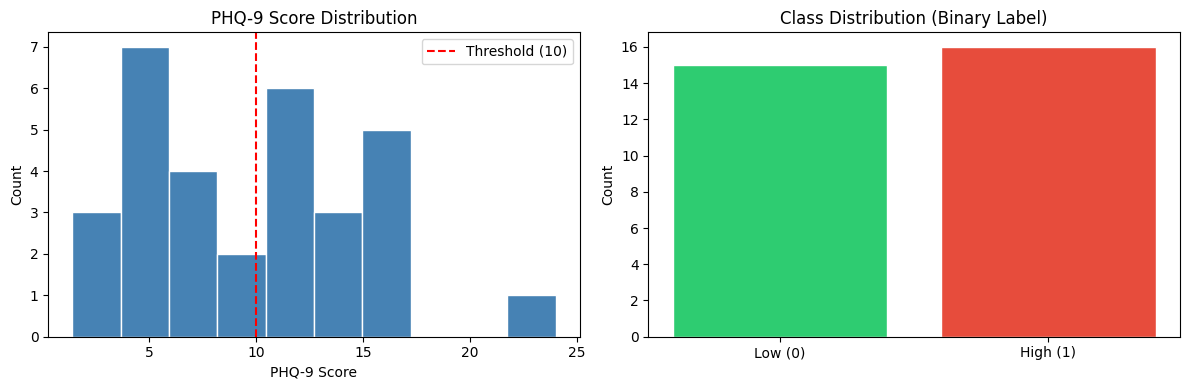

In [19]:
# Visualize PHQ-9 distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(labels_df['phq9_score'].dropna(), bins=10, color='steelblue', edgecolor='white')
axes[0].axvline(x=10, color='red', linestyle='--', label='Threshold (10)')
axes[0].set_title('PHQ-9 Score Distribution')
axes[0].set_xlabel('PHQ-9 Score')
axes[0].set_ylabel('Count')
axes[0].legend()

label_counts = labels_df['phq9_label'].value_counts()
axes[1].bar(['Low (0)', 'High (1)'],
            [label_counts.get(0.0, 0), label_counts.get(1.0, 0)],
            color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[1].set_title('Class Distribution (Binary Label)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('phq9_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 — Merge All Features

In [20]:
# Merge all feature sets on participant_id
merged = labels_df.merge(oura_features, on='participant_id', how='left')
merged = merged.merge(aware_features, on='participant_id', how='left')
merged = merged.merge(ema_features,   on='participant_id', how='left')

print(f"Merged dataset shape: {merged.shape}")
print(f"Participants with labels: {merged['phq9_label'].notna().sum()}")
print(f"\nMissing values per column:")
print(merged.isnull().sum())

Merged dataset shape: (39, 58)
Participants with labels: 31

Missing values per column:
participant_id                  0
phq9_score                      8
phq9_label                      8
oura_sleep_duration_mean        1
oura_sleep_duration_std         1
oura_sleep_total_mean           1
oura_sleep_total_std            1
oura_sleep_deep_mean            1
oura_sleep_deep_std             1
oura_sleep_rem_mean             1
oura_sleep_rem_std              1
oura_sleep_light_mean           1
oura_sleep_light_std            1
oura_sleep_score_mean           1
oura_sleep_score_std            1
oura_sleep_efficiency_mean      1
oura_sleep_efficiency_std       1
oura_sleep_hr_avg_mean          1
oura_sleep_hr_avg_std           1
oura_sleep_hr_lowest_mean       1
oura_sleep_hr_lowest_std        1
oura_sleep_hrv_mean             1
oura_sleep_hrv_std              1
oura_activity_steps_mean        1
oura_activity_steps_std         1
oura_activity_score_mean        1
oura_activity_score_std     

### 3.6 — Handle Missing Values & Prepare Feature Matrix

In [21]:
# Drop rows with missing labels
data = merged.dropna(subset=['phq9_label']).copy()
print(f"Samples after dropping missing labels: {len(data)}")

# Separate features
exclude_cols = ['participant_id', 'phq9_score', 'phq9_label']
feature_cols = [c for c in data.columns if c not in exclude_cols]

X = data[feature_cols].copy()
y = data['phq9_label'].astype(int)

# Drop columns with >50% missing
missing_frac = X.isnull().mean()
drop_cols = missing_frac[missing_frac > 0.5].index.tolist()
print(f"Dropping {len(drop_cols)} columns with >50% missing: {drop_cols}")
X = X.drop(columns=drop_cols)

# Impute remaining with median
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print(f"\nFinal feature matrix: {X_imputed.shape}")
print(f"Features: {list(X_imputed.columns)}")

Samples after dropping missing labels: 31
Dropping 0 columns with >50% missing: []

Final feature matrix: (31, 55)
Features: ['oura_sleep_duration_mean', 'oura_sleep_duration_std', 'oura_sleep_total_mean', 'oura_sleep_total_std', 'oura_sleep_deep_mean', 'oura_sleep_deep_std', 'oura_sleep_rem_mean', 'oura_sleep_rem_std', 'oura_sleep_light_mean', 'oura_sleep_light_std', 'oura_sleep_score_mean', 'oura_sleep_score_std', 'oura_sleep_efficiency_mean', 'oura_sleep_efficiency_std', 'oura_sleep_hr_avg_mean', 'oura_sleep_hr_avg_std', 'oura_sleep_hr_lowest_mean', 'oura_sleep_hr_lowest_std', 'oura_sleep_hrv_mean', 'oura_sleep_hrv_std', 'oura_activity_steps_mean', 'oura_activity_steps_std', 'oura_activity_score_mean', 'oura_activity_score_std', 'oura_activity_cal_mean', 'oura_activity_cal_std', 'oura_activity_high_mean', 'oura_activity_high_std', 'oura_activity_medium_mean', 'oura_activity_medium_std', 'oura_activity_low_mean', 'oura_activity_low_std', 'oura_readiness_score_mean', 'oura_readiness_s

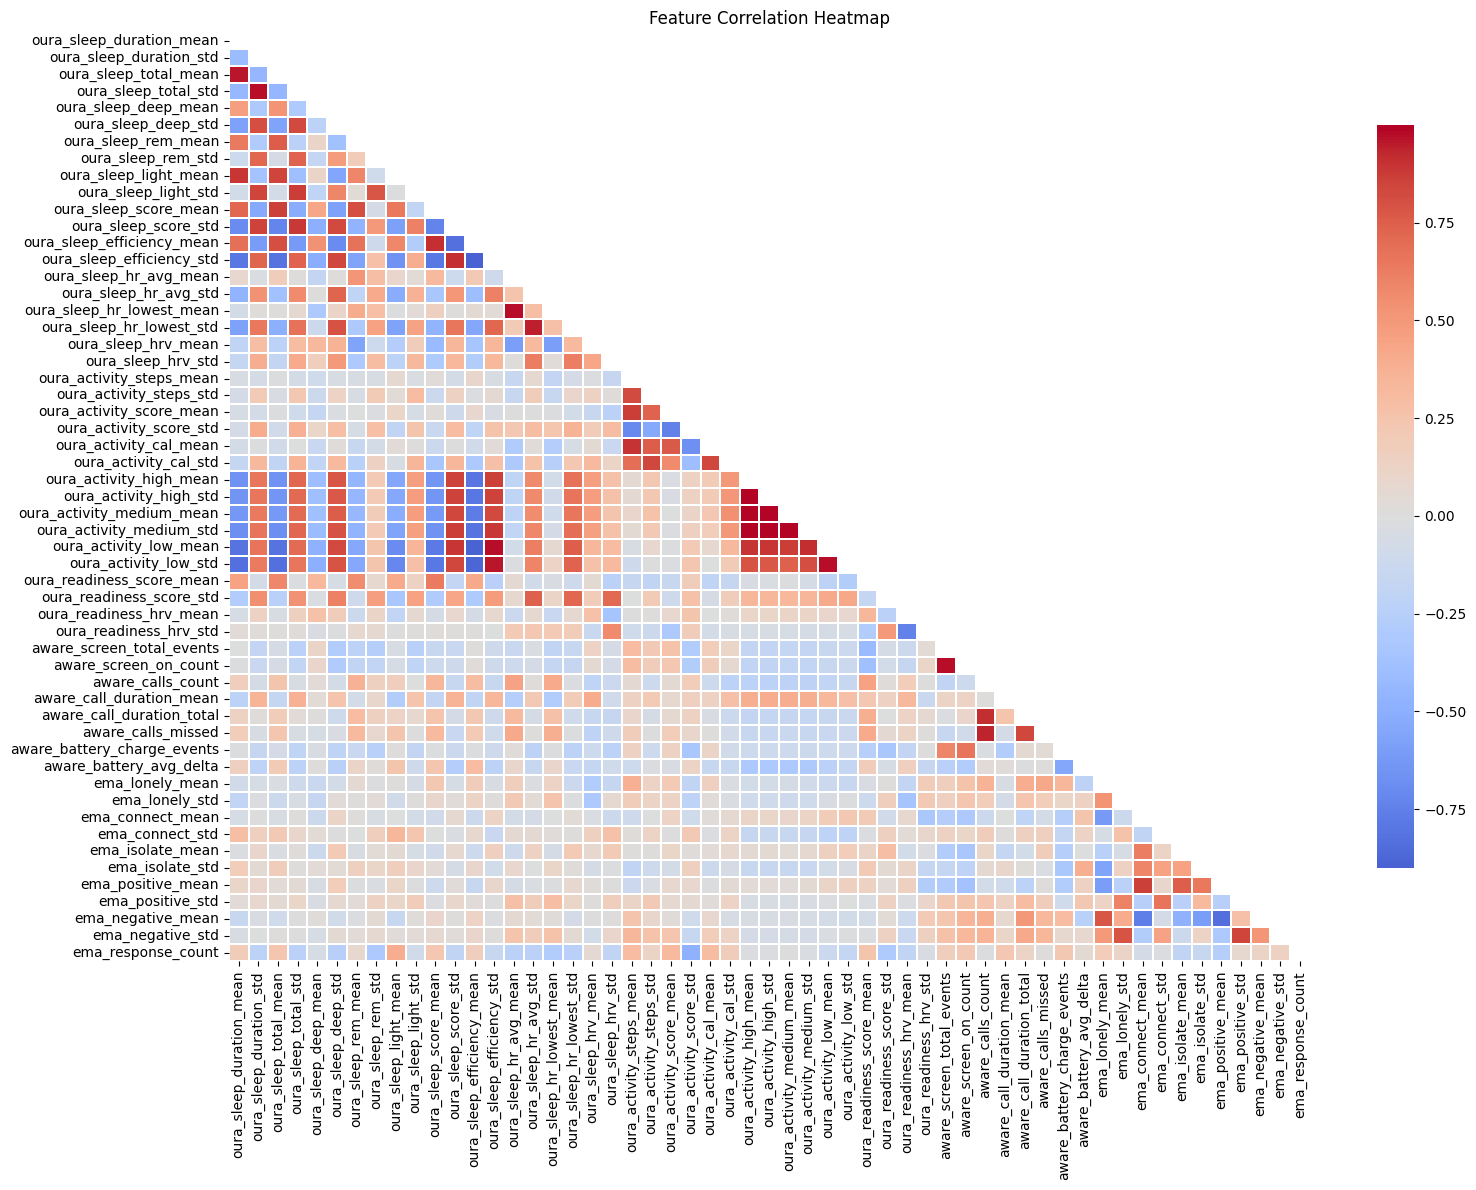

In [22]:
# Correlation heatmap
plt.figure(figsize=(16, 12))
corr = X_imputed.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.3, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Task 4: Define Prediction Task

**Task:** Binary classification — predict whether a participant has high depression severity.

**Target Variable:** PHQ-9 binary label
- `0` = Low/Minimal depression (PHQ-9 average score < 10)
- `1` = High/Moderate-Severe depression (PHQ-9 average score ≥ 10)

**Label Creation:** Each participant completed the PHQ-9 questionnaire weekly. We summed q1–q9 per week to get a total score (range 0–27), then averaged across all weeks to get one score per participant. A threshold of 10 was applied per clinical convention.

In [23]:
# Train/test split — stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.25, random_state=42, stratify=y
)

# Scale features (required for SVM and Neural Network)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"Train class dist : {y_train.value_counts().to_dict()}")
print(f"Test class dist  : {y_test.value_counts().to_dict()}")

Training samples : 23
Test samples     : 8
Train class dist : {1: 12, 0: 11}
Test class dist  : {1: 4, 0: 4}


---
## Task 5: Apply Machine Learning Models

### Model 1: Support Vector Machine (SVM)

In [24]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred  = svm_model.predict(X_test_scaled)
svm_proba = svm_model.predict_proba(X_test_scaled)[:, 1]
print("SVM trained.")
print(classification_report(y_test, svm_pred, target_names=['Low Depression', 'High Depression']))

SVM trained.
                 precision    recall  f1-score   support

 Low Depression       0.40      0.50      0.44         4
High Depression       0.33      0.25      0.29         4

       accuracy                           0.38         8
      macro avg       0.37      0.38      0.37         8
   weighted avg       0.37      0.38      0.37         8



### Model 2: Random Forest

In [25]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=None,
                                   min_samples_split=2, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred  = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]
print("Random Forest trained.")
print(classification_report(y_test, rf_pred, target_names=['Low Depression', 'High Depression']))

Random Forest trained.
                 precision    recall  f1-score   support

 Low Depression       0.75      0.75      0.75         4
High Depression       0.75      0.75      0.75         4

       accuracy                           0.75         8
      macro avg       0.75      0.75      0.75         8
   weighted avg       0.75      0.75      0.75         8



### Model 3: XGBoost

In [26]:
xgb_model = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=4,
                           subsample=0.8, colsample_bytree=0.8,
                           eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred  = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
print("XGBoost trained.")
print(classification_report(y_test, xgb_pred, target_names=['Low Depression', 'High Depression']))

XGBoost trained.
                 precision    recall  f1-score   support

 Low Depression       0.60      0.75      0.67         4
High Depression       0.67      0.50      0.57         4

       accuracy                           0.62         8
      macro avg       0.63      0.62      0.62         8
   weighted avg       0.63      0.62      0.62         8



### Model 4: Neural Network (MLP)

In [27]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=8,
    learning_rate='adaptive',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15
)
mlp_model.fit(X_train_scaled, y_train)
mlp_pred  = mlp_model.predict(X_test_scaled)
mlp_proba = mlp_model.predict_proba(X_test_scaled)[:, 1]
print("Neural Network (MLP) trained.")
print(classification_report(y_test, mlp_pred, target_names=['Low Depression', 'High Depression']))

Neural Network (MLP) trained.
                 precision    recall  f1-score   support

 Low Depression       0.00      0.00      0.00         4
High Depression       0.50      1.00      0.67         4

       accuracy                           0.50         8
      macro avg       0.25      0.50      0.33         8
   weighted avg       0.25      0.50      0.33         8



---
## Task 6: Model Evaluation

In [28]:
def evaluate_model(name, y_true, y_pred, y_proba):
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1 Score':  round(f1_score(y_true, y_pred, zero_division=0), 4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_proba)
                           if len(np.unique(y_true)) > 1 else np.nan, 4),
    }

results = [
    evaluate_model('SVM',            y_test, svm_pred,  svm_proba),
    evaluate_model('Random Forest',  y_test, rf_pred,   rf_proba),
    evaluate_model('XGBoost',        y_test, xgb_pred,  xgb_proba),
    evaluate_model('Neural Network', y_test, mlp_pred,  mlp_proba),
]

results_df = pd.DataFrame(results).set_index('Model')
print("\n=== Model Comparison ===")
print(results_df.to_string())


=== Model Comparison ===
                Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                         
SVM                0.375     0.3333    0.25    0.2857   0.4062
Random Forest      0.750     0.7500    0.75    0.7500   0.6562
XGBoost            0.625     0.6667    0.50    0.5714   0.7500
Neural Network     0.500     0.5000    1.00    0.6667   0.5938


In [29]:
# 5-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_scaled_full = scaler.fit_transform(X_imputed)

cv_models = {
    'SVM':            (SVC(kernel='rbf', probability=True, random_state=42),            X_scaled_full),
    'Random Forest':  (RandomForestClassifier(n_estimators=200, random_state=42),       X_imputed.values),
    'XGBoost':        (XGBClassifier(n_estimators=200, eval_metric='logloss', random_state=42), X_imputed.values),
    'Neural Network': (MLPClassifier(hidden_layer_sizes=(128,64,32), max_iter=500, random_state=42), X_scaled_full),
}

print("\n=== 5-Fold Cross-Validation F1 Scores ===")
cv_results = {}
for name, (model, X_data) in cv_models.items():
    scores = cross_val_score(model, X_data, y, cv=cv, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:20s}: {scores.mean():.4f} ± {scores.std():.4f}")


=== 5-Fold Cross-Validation F1 Scores ===
SVM                 : 0.6635 ± 0.2029
Random Forest       : 0.7111 ± 0.2031
XGBoost             : 0.7035 ± 0.1881
Neural Network      : 0.7119 ± 0.1587


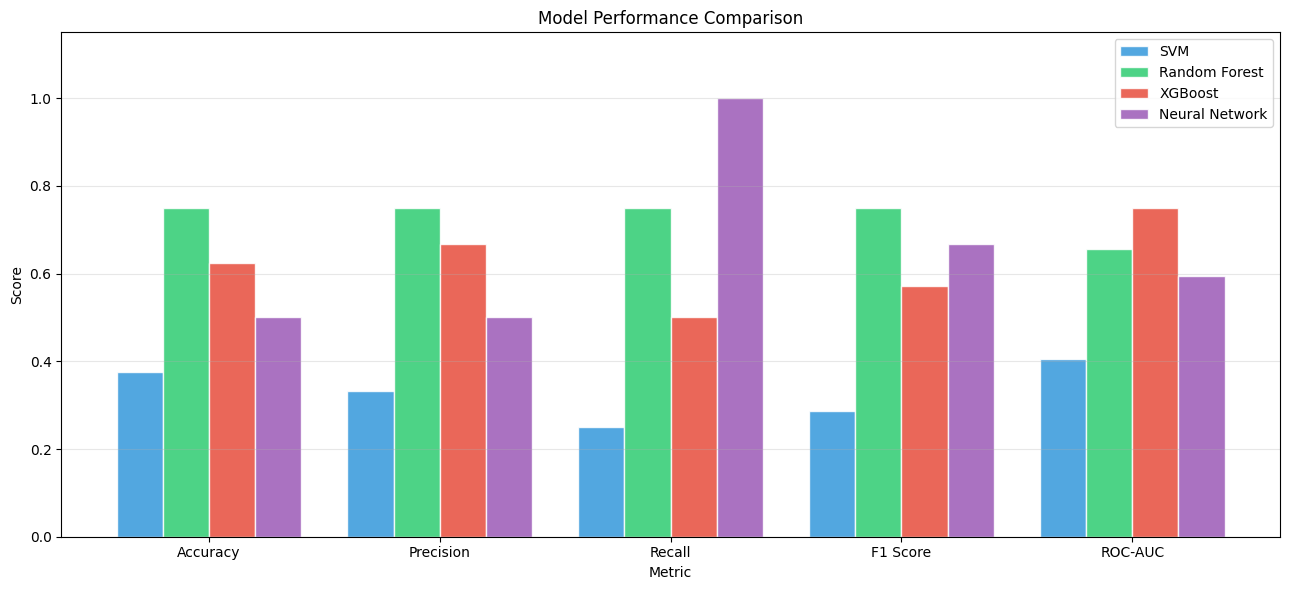

In [30]:
# Model comparison bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.2
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (model_name, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics]
    ax.bar(x + i * width, vals, width, label=model_name, color=colors[i], alpha=0.85, edgecolor='white')

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

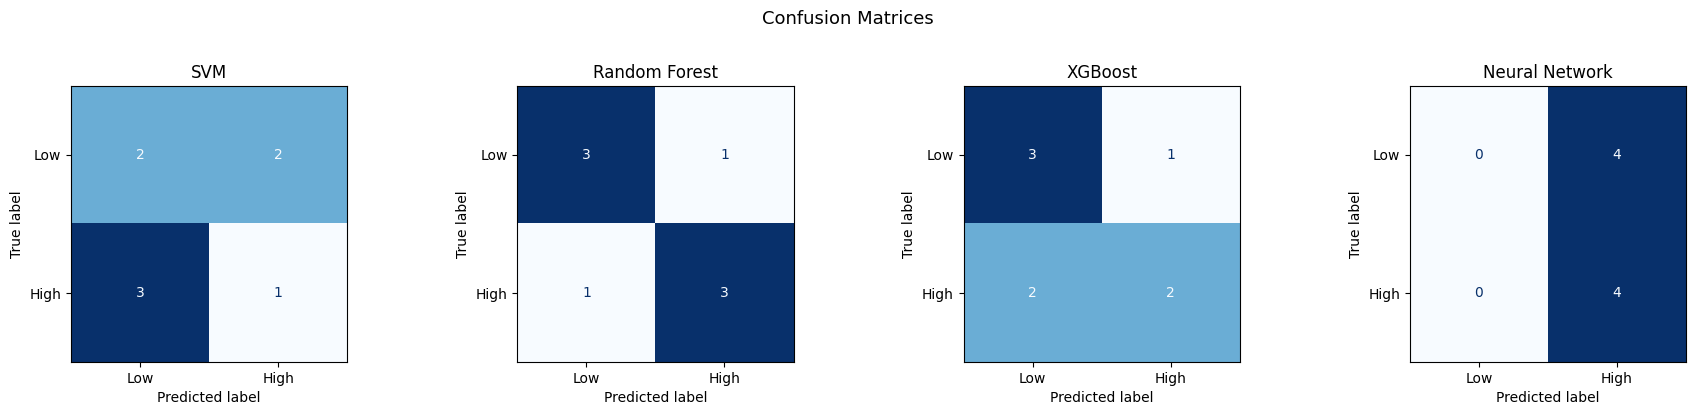

In [31]:
# Confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
model_preds = [
    ('SVM', svm_pred), ('Random Forest', rf_pred),
    ('XGBoost', xgb_pred), ('Neural Network', mlp_pred)
]
for ax, (name, pred) in zip(axes, model_preds):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['Low', 'High']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.suptitle('Confusion Matrices', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

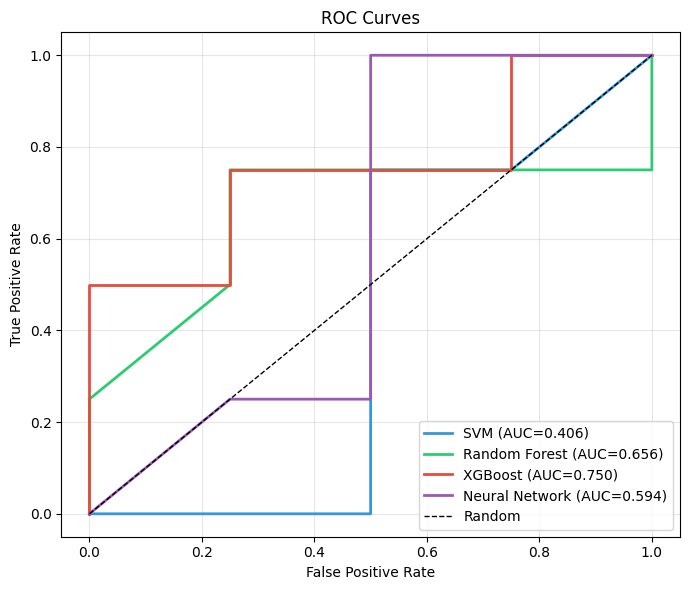

In [32]:
# ROC Curves
fig, ax = plt.subplots(figsize=(7, 6))
for (name, proba), color in zip(
    [('SVM', svm_proba), ('Random Forest', rf_proba),
     ('XGBoost', xgb_proba), ('Neural Network', mlp_proba)], colors):
    if len(np.unique(y_test)) > 1:
        fpr, tpr, _ = roc_curve(y_test, proba)
        auc = roc_auc_score(y_test, proba)
        ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=2)
ax.plot([0,1],[0,1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Task 7: Result Analysis

### 7.1 — Feature Importance

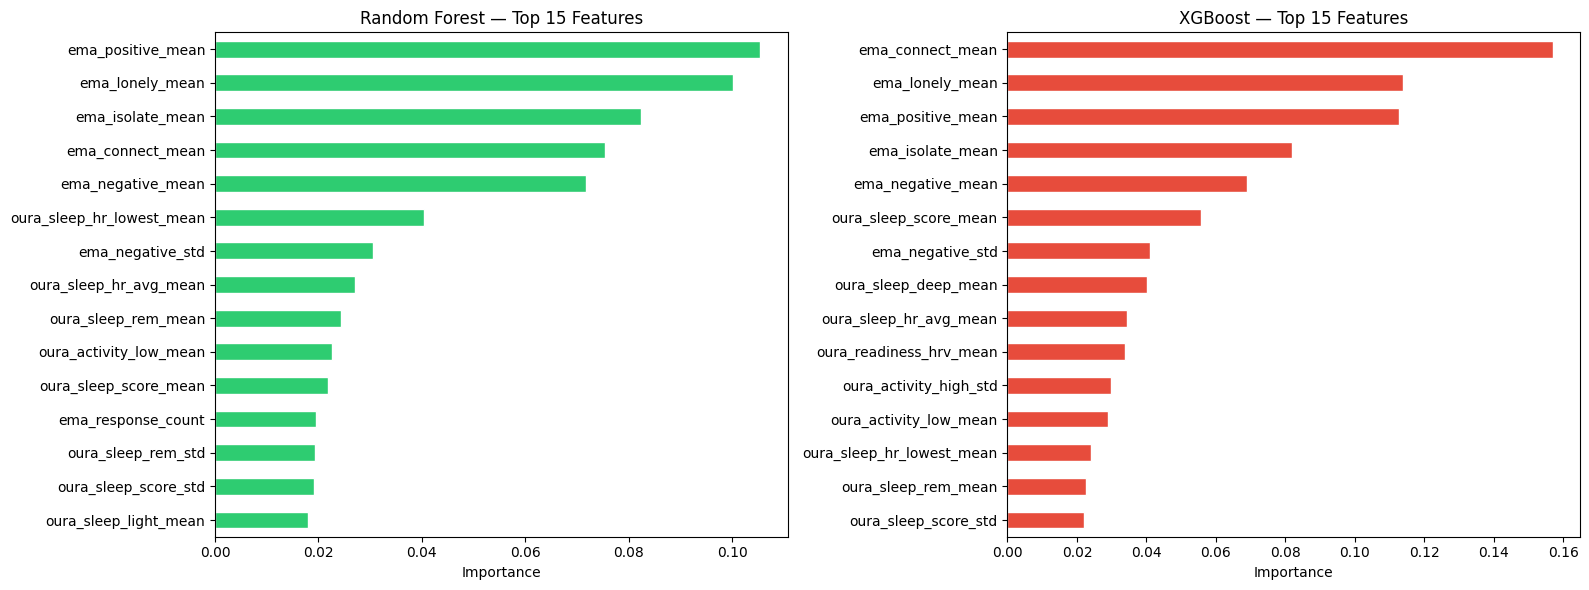


Top 10 RF Features:
ema_positive_mean            0.105403
ema_lonely_mean              0.100151
ema_isolate_mean             0.082305
ema_connect_mean             0.075306
ema_negative_mean            0.071639
oura_sleep_hr_lowest_mean    0.040387
ema_negative_std             0.030528
oura_sleep_hr_avg_mean       0.027139
oura_sleep_rem_mean          0.024445
oura_activity_low_mean       0.022691
dtype: float64


In [33]:
rf_importances  = pd.Series(rf_model.feature_importances_,  index=X_imputed.columns).sort_values(ascending=False).head(15)
xgb_importances = pd.Series(xgb_model.feature_importances_, index=X_imputed.columns).sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
rf_importances.plot(kind='barh',  ax=axes[0], color='#2ecc71', edgecolor='white')
axes[0].set_title('Random Forest — Top 15 Features')
axes[0].set_xlabel('Importance')
axes[0].invert_yaxis()

xgb_importances.plot(kind='barh', ax=axes[1], color='#e74c3c', edgecolor='white')
axes[1].set_title('XGBoost — Top 15 Features')
axes[1].set_xlabel('Importance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 RF Features:")
print(rf_importances.head(10))

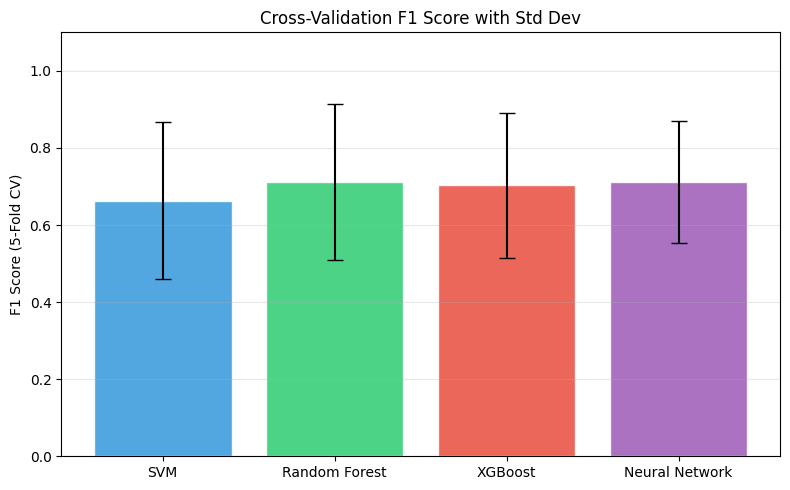

In [34]:
# Cross-validation summary
fig, ax = plt.subplots(figsize=(8, 5))
model_names = list(cv_results.keys())
means = [cv_results[m].mean() for m in model_names]
stds  = [cv_results[m].std()  for m in model_names]
ax.bar(model_names, means, yerr=stds, capsize=6, color=colors, alpha=0.85, edgecolor='white')
ax.set_ylabel('F1 Score (5-Fold CV)')
ax.set_title('Cross-Validation F1 Score with Std Dev')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
# Final summary
print("\n" + "="*60)
print(" FINAL MODEL COMPARISON")
print("="*60)
print(results_df.to_string())
print(f"\nBest model by F1 Score : {results_df['F1 Score'].idxmax()}")
print(f"Best model by ROC-AUC  : {results_df['ROC-AUC'].idxmax()}")


 FINAL MODEL COMPARISON
                Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                         
SVM                0.375     0.3333    0.25    0.2857   0.4062
Random Forest      0.750     0.7500    0.75    0.7500   0.6562
XGBoost            0.625     0.6667    0.50    0.5714   0.7500
Neural Network     0.500     0.5000    1.00    0.6667   0.5938

Best model by F1 Score : Random Forest
Best model by ROC-AUC  : XGBoost
